<a href="https://colab.research.google.com/github/mrabinayaa/DAAexps/blob/main/exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

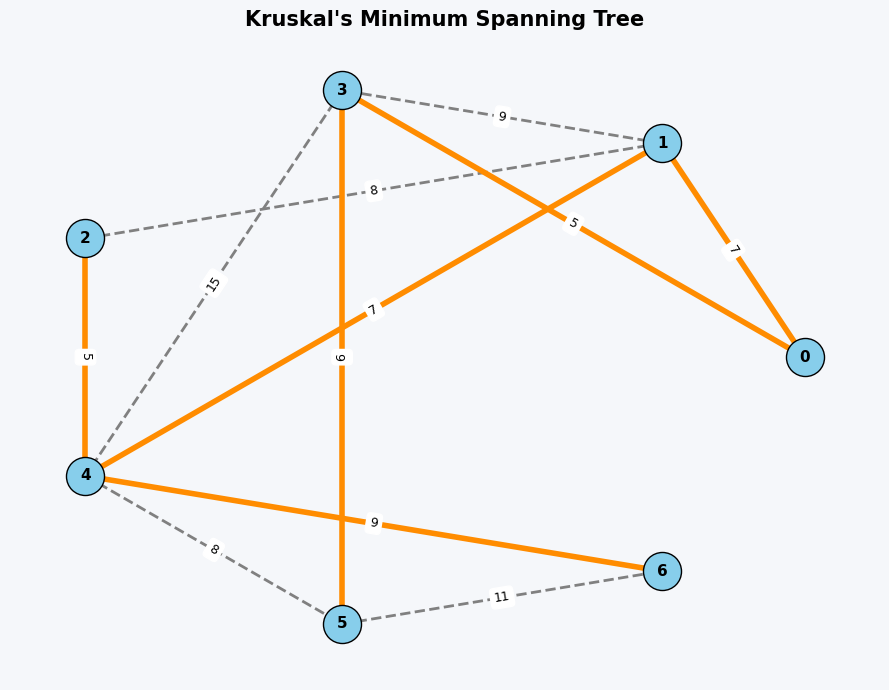

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# ---------- Disjoint Set ----------

class DisjointSet:

    def __init__(self, vertices):
        self.root = {}
        for v in vertices:
            self.root[v] = v

    def get_parent(self, node):
        while self.root[node] != node:
            node = self.root[node]
        return node

    def merge(self, a, b):
        p1 = self.get_parent(a)
        p2 = self.get_parent(b)

        if p1 == p2:
            return False

        self.root[p2] = p1
        return True


# ---------- Kruskal Algorithm ----------

def find_mst(vertex_count, edge_list):

    vertices = list(range(vertex_count))
    ds = DisjointSet(vertices)

    chosen_edges = []

    for weight, source, destination in sorted(edge_list):

        if ds.merge(source, destination):
            chosen_edges.append((source, destination, weight))

        if len(chosen_edges) == vertex_count - 1:
            break

    return chosen_edges


# ---------- Input Graph ----------

vertices = 7

graph_edges = [
    (7,0,1),
    (5,0,3),
    (8,1,2),
    (9,1,3),
    (7,1,4),
    (5,2,4),
    (15,3,4),
    (6,3,5),
    (8,4,5),
    (9,4,6),
    (11,5,6)
]


# ---------- Compute MST ----------

mst = find_mst(vertices, graph_edges)


# ---------- Build Graph ----------

graph = nx.Graph()

for weight, u, v in graph_edges:
    graph.add_edge(u, v, weight=weight)


# ---------- Draw Graph ----------

layout = nx.circular_layout(graph)

plt.figure(figsize=(9,7), facecolor="#F5F7FA")

# Store MST edges
mst_list = {(min(u,v), max(u,v)) for u,v,w in mst}

ordinary = []
highlight = []

for u, v in graph.edges():

    if (min(u,v), max(u,v)) in mst_list:
        highlight.append((u,v))
    else:
        ordinary.append((u,v))


# Draw normal edges
nx.draw_networkx_edges(
    graph,
    layout,
    edgelist=ordinary,
    edge_color="gray",
    style="dashed",
    width=2
)

# Draw MST
nx.draw_networkx_edges(
    graph,
    layout,
    edgelist=highlight,
    edge_color="darkorange",
    width=4
)

# Draw nodes
nx.draw_networkx_nodes(
    graph,
    layout,
    node_color="skyblue",
    node_size=750,
    edgecolors="black"
)

# Labels
nx.draw_networkx_labels(
    graph,
    layout,
    font_size=11,
    font_weight="bold"
)

# Edge weights
weights = nx.get_edge_attributes(graph, "weight")

nx.draw_networkx_edge_labels(
    graph,
    layout,
    edge_labels=weights,
    font_size=9
)

plt.title(
    "Kruskal's Minimum Spanning Tree",
    fontsize=15,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()